# Emitted electrons from p-GaAs as a `ParticleGroup`

This notebook runs the full model — photoexcitation, transport (Chubenko 2021 physics, C21 band
bending) and the C21 surface model — for a chosen set of initial conditions, and returns the emitted
electrons as an [openPMD-beamphysics](https://github.com/ChristopherMayes/openPMD-beamphysics)
`ParticleGroup`.

**Output convention** (output only; the simulation itself is unchanged): the simulation places the
GaAs at z > 0 and emits toward −z. In the `ParticleGroup`, z → −z and p_z → −p_z, so the beam travels
along **+z**. All particles start at z = 0 (the surface); `t` is the emission time after the
δ-function excitation pulse at t = 0; momenta are the vacuum momenta just outside the surface (eV/c).
The transport is one-dimensional in space, so x and y come from the laser spot (`sigma_xy`), not
from lateral motion inside the cathode.

Speed: on a CUDA GPU (`device="auto"` picks it) 10⁵ electrons to 370 ps take ~1 min; on the CPU the
compiled engine is ~8× slower (first call compiles for ~35 s).

In [1]:
import sys, pathlib, warnings
warnings.simplefilter("ignore", DeprecationWarning)
# make the repository importable when the notebook is opened from examples/
root = pathlib.Path.cwd().resolve()
while not (root / "gaas_mc").is_dir() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

import numpy as np
import matplotlib.pyplot as plt

from gaas_mc.emission import simulate_emission
from gaas_mc.constants import PS, Q_E

## Initial conditions

| parameter | meaning |
|---|---|
| `hv_eV` | photon energy (eV); the gap at 1e19 cm⁻³ is 1.361 eV |
| `p_cm3` | acceptor (hole) density (cm⁻³) |
| `chi_eV` | electron affinity of the C21 surface model (eV); χ_eff = χ − E_bb (E_bb = 0.694 eV at 1e19) |
| `n` | photoexcited electrons simulated |
| `t_max_ps` | simulation time (C21: 370 ps, the recombination time at 1e19) |
| `thickness_nm`, `R_back` | `None` = semi-infinite cathode; otherwise a GaAs layer of this thickness with back-boundary reflection coefficient `R_back` |
| `depletion_scattering` | `"bulk"` (C21 baseline) or `"local"` (holes depleted in the band-bending region) |
| `sigma_xy` | rms laser spot size per axis (m) for x, y |
| `total_charge` | bunch charge (C) for the weights; `None` = one electron per macroparticle |

In [2]:
params = dict(
    hv_eV=1.55,
    p_cm3=1e19,
    chi_eV=0.67,
    n=100_000,
    t_max_ps=370.0,
    thickness_nm=None,          # e.g. 200 for a 200 nm layer
    R_back=0.0,                 # used only with thickness_nm
    depletion_scattering="bulk",
    sigma_xy=0.5e-3,            # 0.5 mm rms laser spot
    total_charge=None,
    device="auto",
    seed=1,
)

In [3]:
run = simulate_emission(**params)
pg = run.particle_group
print(f"device: {run.settings['device']}")
print(f"generated {run.n_generated}, emitted {run.n_emitted}")
print(f"absorbed fraction of the light {run.absorbed_fraction:.3f}")
print(f"QE  = {100 * run.qe:.2f} %")
print(f"ESP = {100 * run.esp:.1f} % (spin polarization of the emitted electrons)")
pg

device: cuda
generated 100000, emitted 7959
absorbed fraction of the light 0.680
QE  = 5.41 %
ESP = 24.8 % (spin polarization of the emitted electrons)


<ParticleGroup with 7959 particles at 0x2539c5d3b60>

## Beam quantities from the `ParticleGroup`

In [4]:
mc2 = 510998.95   # eV
MTE = np.mean(pg.px**2 + pg.py**2) / (2 * mc2)
print(f"mean kinetic energy      {1e3 * pg['mean_kinetic_energy']:.1f} meV")
print(f"MTE = <px^2 + py^2>/2m   {1e3 * MTE:.1f} meV")
print(f"normalized emittance x   {1e6 * pg['norm_emit_x']:.3f} um   (sigma_x = {1e3 * pg['sigma_x']:.3f} mm)")
print(f"mean / rms emission time {pg['mean_t'] / PS:.1f} / {pg['sigma_t'] / PS:.1f} ps")

mean kinetic energy      96.3 meV
MTE = <px^2 + py^2>/2m   12.2 meV
normalized emittance x   0.077 um   (sigma_x = 0.498 mm)
mean / rms emission time 96.2 / 101.7 ps


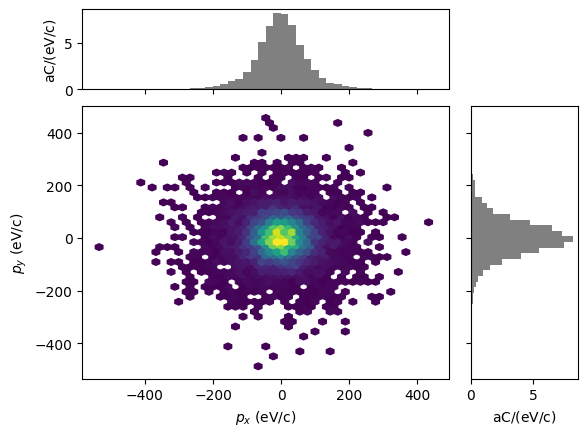

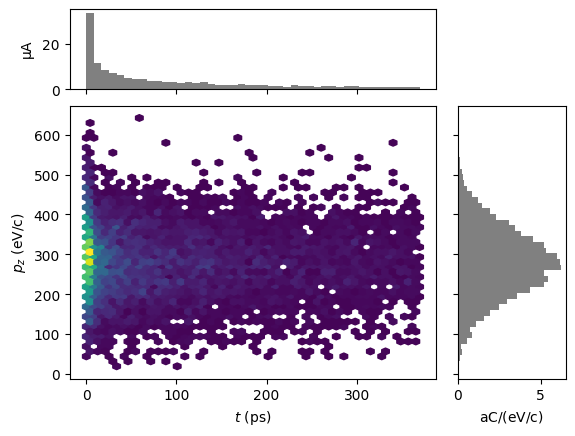

In [5]:
pg.plot("px", "py")
pg.plot("t", "pz")

## Distributions and spin

Spin, the emission valley and the other per-electron records are not part of a `ParticleGroup`; they
are in `run.emissions`. Early electrons are much more strongly polarized than the late, diffusive
tail.

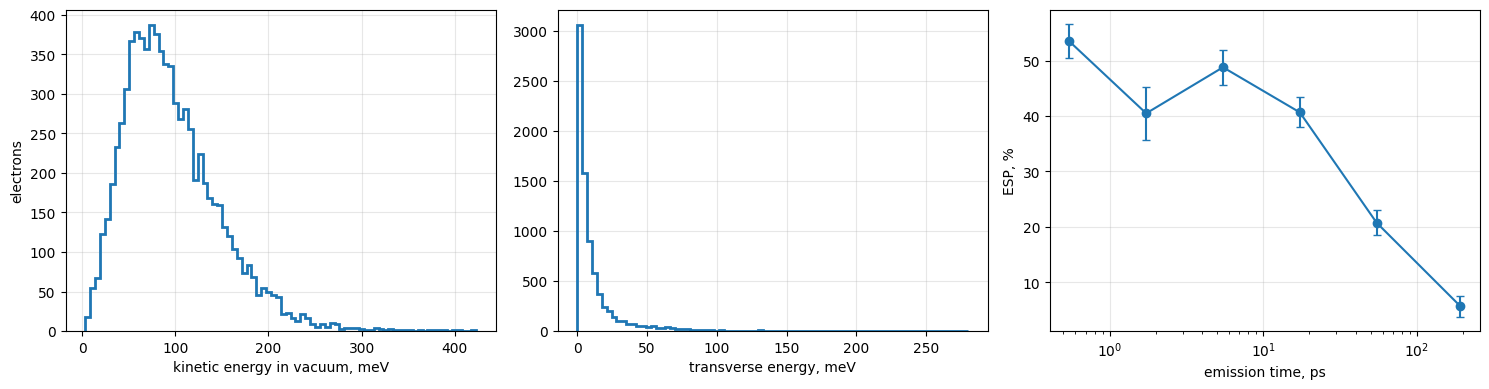

In [6]:
em = run.emissions
E_vac = em.E_vac / Q_E * 1e3            # kinetic energy in vacuum, meV
t = em.t / PS

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].hist(E_vac, bins=80, histtype="step", lw=2)
axs[0].set_xlabel("kinetic energy in vacuum, meV"); axs[0].set_ylabel("electrons")
E_perp = (em.p_vac[:, 0]**2 + em.p_vac[:, 1]**2) / (2 * 9.1093837e-31) / Q_E * 1e3
axs[1].hist(E_perp, bins=80, histtype="step", lw=2)
axs[1].set_xlabel("transverse energy, meV")
edges = np.array([0, 1, 3, 10, 30, 100, 370])
mid, esp, err = [], [], []
for a, b in zip(edges[:-1], edges[1:]):
    s = em.spin[(t >= a) & (t < b)]
    if s.size:
        mid.append(np.sqrt(max(a, 0.3) * b)); esp.append(100 * s.mean())
        err.append(100 * np.sqrt((1 - s.mean()**2) / s.size))
axs[2].errorbar(mid, esp, yerr=err, marker="o", capsize=3)
axs[2].set_xscale("log"); axs[2].set_xlabel("emission time, ps"); axs[2].set_ylabel("ESP, %")
for ax in axs:
    ax.grid(alpha=0.3)
plt.tight_layout()

## Save (openPMD HDF5)

In [7]:
out = root / "examples" / "out"
out.mkdir(parents=True, exist_ok=True)
pg.write(str(out / "emitted_electrons.h5"))
print("wrote", out / "emitted_electrons.h5")

wrote C:\Users\acb20\OneDrive\Desktop\Claude\GaAsTransport\examples\out\emitted_electrons.h5


## Optional: a small thickness scan

Each call is independent, so loops over any parameter are straightforward. (Set `scan = True`.)

In [8]:
scan = False
if scan:
    for d in (100, 200, 500, None):
        r = simulate_emission(**{**params, "thickness_nm": d, "R_back": 0.0, "n": 50_000})
        print(f"d = {d} nm: QE {100 * r.qe:.2f} %, ESP {100 * r.esp:.1f} %, "
              f"median emission time {np.median(r.emissions.t) / PS:.1f} ps")